# Assignment 1 — EDA and Monte Carlo
## Pennsylvania County Income and Community Outreach Planning
**OPIM 5641 · Business Decision Modeling**

This notebook explores county income differences and asks a planning question: **If 30 outreach events independently select Pennsylvania counties with equal probability, what is the probability that the average county per capita income across their locations is below $25,000?**

The workflow follows M1.1 (load, clean, summarize, visualize, enrich) and M1.2 (random draws, a loop, and probability interpretation). The data and planning scenario differ from the classroom examples. All code and narrative are included here. Run cells from top to bottom in Google Colab.

The dollar threshold is a hypothetical teaching benchmark in the historical data's dollars, not an official eligibility rule. The modeled uncertainty is **which counties host events**, not future income growth or the earnings of individual attendees.

[Open in Colab](https://colab.research.google.com/github/chong-guo/opim5641-work/blob/main/Assignment_1/Assignment_1_PA_Income_MC.ipynb)

## 1. Data sources and observation unit

| Source | Coverage and role | Fields used |
|---|---|---|
| [Wikipedia: Pennsylvania counties by per capita income](https://en.wikipedia.org/wiki/List_of_Pennsylvania_counties_by_per_capita_income) | County summary table; the table identifies 2010 Census and 2006–2010 ACS five-year estimates | County, three income measures, population, households |
| [US Census Bureau: 2023 Pennsylvania County Gazetteer](https://www2.census.gov/geo/docs/maps-data/data/gazetteer/2023_Gazetteer/2023_gaz_counties_42.txt) | External geographic enrichment | GEOID, land area, internal-point latitude/longitude |

**One cleaned row is one county.** Per capita income is dollars per resident; median household and family incomes are different county summaries. Population and household counts are counts, not income. Gazetteer `ALAND_SQMI` is land area in square miles; coordinates identify an internal point, not an event address.

Sources were retrieved on **2026-09-21 UTC (2026-09-20 Eastern)**. The page introduction mentions other years: I use the county table's stated vintage and do not label its values as current. Wikipedia may contain transcription errors; the Census geography join checks coverage, not the correctness of income values. The geographic file is newer than the income table, so the merged analysis is descriptive, not a synchronized 2023 socioeconomic dataset.

In [1]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib.ticker import StrMethodFormatter

plt.rcParams.update({'figure.dpi':115, 'axes.spines.top':False, 'axes.spines.right':False})
pd.options.display.float_format = '{:,.2f}'.format

## 2. Load reproducible source snapshots
The two small original-format tables are embedded below so this notebook runs without uploads, API keys, or a changing webpage. Identical files are stored in `Assignment_1/data/` in GitHub. No values have been imputed in these snapshots.

The income table was obtained with `requests.get(..., headers={'User-Agent': ...})` and `pd.read_html(io.StringIO(response.text))`, choosing the table containing County and Per capita income columns. The Gazetteer was read as tab-delimited text. To update the study, retrieve both sources again, review their vintages, and rerun every validation and interpretation.

In [2]:
# Raw source snapshots; keep these strings unchanged to reproduce the submitted analysis.
INCOME_CSV = 'Rank,County,Per capita income,Median household income,Median family income,Population,Number of households\n*,United States,"$27,334","$51,914","$62,982",308745538.0,116716292.0\n*,Pennsylvania,"$27,049","$50,398","$63,364",12702379.0,5018904.0\n1,Chester,"$41,251","$84,741","$94,592",498886.0,307750.0\n2,Montgomery,"$40,076","$76,380","$94,592",799874.0,\n3,Bucks,"$35,687","$74,828","$90,274",625249.0,234849.0\n4,Delaware,"$32,067","$61,876","$77,879",558979.0,208700.0\n5,Cumberland,"$30,119","$60,219","$75,000",235406.0,93943.0\n6,Allegheny,"$29,549","$47,961","$65,678",1223348.0,533960.0\n7,Butler,"$28,446","$56,878","$69,464",183862.0,72835.0\n8,Northampton,"$28,362","$58,762","$70,457",297735.0,113565.0\n9,Dauphin,"$27,727","$52,371","$66,023",268100.0,110435.0\n10,Pike,"$27,564","$56,843","$62,982",57369.0,21925.0\n11,Lehigh,"$27,301","$53,541","$66,004",349497.0,133983.0\n12,York,"$27,196","$57,494","$67,624",434972.0,168372.0\n13,Montour,"$26,124","$45,255","$57,011",18267.0,7393.0\n14,Washington,"$26,045","$49,687","$63,690",207820.0,85089.0\n15,Lancaster,"$25,854","$54,765","$64,672",519445.0,193602.0\n16,Westmoreland,"$25,845","$47,689","$60,987",365169.0,153650.0\n17,Adams,"$25,606","$56,529","$66,222",101407.0,38013.0\n18,Lebanon,"$25,525","$52,356","$62,174",133568.0,52258.0\n19,Berks,"$25,518","$53,470","$63,724",411442.0,154356.0\n20,Franklin,"$25,307","$51,035","$61,410",149618.0,58389.0\n21,Monroe,"$24,824","$56,733","$64,763",169842.0,61091.0\n22,Beaver,"$24,168","$46,190","$57,201",170539.0,71383.0\n23,Lackawanna,"$24,152","$43,673","$57,846",214437.0,87226.0\n24,Centre,"$23,744","$47,016","$65,121",153990.0,57573.0\n25,Perry,"$23,701","$52,659","$61,221",45969.0,17903.0\n26,Luzerne,"$23,245","$42,224","$54,843",320918.0,131932.0\n27,Carbon,"$22,956","$47,744","$54,918",65249.0,26684.0\n28,Wyoming,"$22,899","$47,403","$56,957",28276.0,11237.0\n29,Blair,"$22,880","$42,363","$53,166",127089.0,52159.0\n30,Elk,"$22,729","$43,745","$51,889",31946.0,13693.0\n31,Erie,"$22,644","$43,595","$56,144",280566.0,110413.0\n32,Wayne,"$22,525","$45,930","$53,665",52822.0,20625.0\n33,Columbia,"$22,403","$42,788","$52,959",67295.0,26479.0\n34,Susquehanna,"$22,173","$43,457","$51,151",43356.0,17798.0\n35,Warren,"$22,170","$41,286","$52,587",41815.0,17767.0\n36,Armstrong,"$21,828","$42,752","$52,085",68941.0,28713.0\n37,Lycoming,"$21,802","$42,689","$52,124",116111.0,46700.0\n38,Mercer,"$21,765","$42,573","$54,160",116638.0,46442.0\n39,Fulton,"$21,739","$45,240","$54,946",14845.0,6014.0\n40,Union,"$21,612","$45,474","$52,664",44947.0,14765.0\n41,Lawrence,"$21,467","$42,570","$52,370",91108.0,37126.0\n42,Schuylkill,"$21,408","$42,315","$53,083",148289.0,60192.0\n43,Cameron,"$21,375","$40,733","$49,922",5085.0,2273.0\n44,Cambria,"$21,278","$39,574","$50,900",143679.0,58950.0\n45,Philadelphia,"$21,117","$36,251","$45,619",1526006.0,599736.0\n46,Snyder,"$21,072","$44,713","$51,715",39702.0,14750.0\n47,McKean,"$21,022","$40,097","$50,000",43450.0,17183.0\n48,Bradford,"$20,979","$40,543","$50,142",62622.0,25321.0\n49,Juniata,"$20,682","$44,276","$52,489",24636.0,9476.0\n50,Northumberland,"$20,654","$38,387","$48,708",94528.0,39242.0\n51,Huntingdon,"$20,616","$41,700","$51,969",45913.0,17280.0\n52,Potter,"$20,594","$39,196","$47,995",17457.0,7227.0\n53,Indiana,"$20,587","$40,225","$51,227",88880.0,35005.0\n54,Bedford,"$20,545","$40,249","$48,825",49762.0,20233.0\n55,Venango,"$20,522","$39,812","$48,866",54984.0,22621.0\n56,Crawford,"$20,383","$38,924","$48,557",88765.0,35028.0\n57,Tioga,"$20,358","$40,338","$48,382",41981.0,16727.0\n58,Jefferson,"$20,305","$38,406","$47,051",45200.0,18561.0\n59,Clarion,"$20,259","$40,028","$50,697",39988.0,16128.0\n60,Greene,"$20,258","$40,498","$49,488",38686.0,14724.0\n61,Clearfield,"$20,142","$37,130","$46,735",81642.0,32288.0\n62,Somerset,"$19,903","$39,194","$48,994",77742.0,31090.0\n63,Sullivan,"$19,718","$36,250","$48,168",6428.0,2777.0\n64,Clinton,"$19,261","$39,354","$50,055",39238.0,15151.0\n65,Fayette,"$19,209","$34,796","$44,114",136606.0,55997.0\n66,Mifflin,"$19,085","$37,539","$46,598",46682.0,18743.0\n67,Forest,"$14,325","$35,150","$43,750",7716.0,2511.0\n,,,,,,\n'

GAZETTEER_TSV = 'USPS\tGEOID\tANSICODE\tNAME\tALAND\tAWATER\tALAND_SQMI\tAWATER_SQMI\tINTPTLAT\tINTPTLONG                                                                                                               \nPA\t42001\t01213656\tAdams County\t1343409411\t7762899\t518.693\t2.997\t39.869471\t-77.21773                                                                                                                     \nPA\t42003\t01213657\tAllegheny County\t1890579938\t37035881\t729.957\t14.3\t40.469757\t-79.980451                                                                                                                \nPA\t42005\t01213658\tArmstrong County\t1692093660\t27586719\t653.321\t10.651\t40.81238\t-79.464129                                                                                                               \nPA\t42007\t01214112\tBeaver County\t1125854807\t24162294\t434.695\t9.329\t40.68414\t-80.350721                                                                                                                   \nPA\t42009\t01209171\tBedford County\t2621037920\t11998904\t1011.988\t4.633\t39.998634\t-78.494747                                                                                                                \nPA\t42011\t01209172\tBerks County\t2218072315\t24220126\t856.403\t9.351\t40.413957\t-75.92686                                                                                                                    \nPA\t42013\t01213659\tBlair County\t1359916303\t3294803\t525.067\t1.272\t40.498683\t-78.309597                                                                                                                    \nPA\t42015\t01213660\tBradford County\t2971688854\t35331261\t1147.376\t13.641\t41.791504\t-76.502123                                                                                                              \nPA\t42017\t01209173\tBucks County\t1565304253\t45293397\t604.367\t17.488\t40.336887\t-75.10706                                                                                                                   \nPA\t42019\t01213661\tButler County\t2044750110\t16004632\t789.482\t6.179\t40.913847\t-79.918978                                                                                                                  \nPA\t42021\t01213662\tCambria County\t1781816295\t13645124\t687.963\t5.268\t40.510209\t-78.710488                                                                                                                 \nPA\t42023\t01213663\tCameron County\t1026239937\t5653225\t396.233\t2.183\t41.438291\t-78.198323                                                                                                                  \nPA\t42025\t01213664\tCarbon County\t987706484\t15918751\t381.356\t6.146\t40.918367\t-75.705039                                                                                                                   \nPA\t42027\t01214720\tCentre County\t2867787637\t11295681\t1107.259\t4.361\t40.909322\t-77.847667                                                                                                                 \nPA\t42029\t01209174\tChester County\t1943908013\t22410055\t750.547\t8.653\t39.974029\t-75.749751                                                                                                                 \nPA\t42031\t01210234\tClarion County\t1556156937\t23330902\t600.836\t9.008\t41.198159\t-79.420369                                                                                                                 \nPA\t42033\t01209175\tClearfield County\t2965691769\t24125590\t1145.06\t9.315\t41.006862\t-78.477724                                                                                                              \nPA\t42035\t01214721\tClinton County\t2304129979\t23182058\t889.63\t8.951\t41.239508\t-77.629009                                                                                                                  \nPA\t42037\t01213665\tColumbia County\t1251636166\t18574480\t483.259\t7.172\t41.045517\t-76.40426                                                                                                                 \nPA\t42039\t01213666\tCrawford County\t2621988043\t65390015\t1012.355\t25.247\t41.687876\t-80.107795                                                                                                              \nPA\t42041\t01209176\tCumberland County\t1412792253\t12666284\t545.482\t4.89\t40.164805\t-77.263442                                                                                                               \nPA\t42043\t01213667\tDauphin County\t1359407363\t86047350\t524.87\t33.223\t40.412565\t-76.792634                                                                                                                 \nPA\t42045\t01209177\tDelaware County\t476068775\t17591835\t183.811\t6.792\t39.916685\t-75.398818                                                                                                                 \nPA\t42047\t01213668\tElk County\t2141664027\t12792134\t826.901\t4.939\t41.427332\t-78.653937                                                                                                                     \nPA\t42049\t01209178\tErie County\t2069143912\t1966272916\t798.901\t759.182\t42.117952\t-80.096386                                                                                                                \nPA\t42051\t01209179\tFayette County\t2048054609\t20636361\t790.758\t7.968\t39.918907\t-79.640119                                                                                                                 \nPA\t42053\t01213669\tForest County\t1106595595\t8369676\t427.259\t3.232\t41.513304\t-79.249705                                                                                                                   \nPA\t42055\t01213670\tFranklin County\t2000239709\t1553435\t772.297\t0.6\t39.926772\t-77.724521                                                                                                                   \nPA\t42057\t01213671\tFulton County\t1133252799\t1305486\t437.551\t0.504\t39.91075\t-78.122617                                                                                                                    \nPA\t42059\t01214033\tGreene County\t1491658047\t5296803\t575.932\t2.045\t39.847707\t-80.225655                                                                                                                   \nPA\t42061\t01213672\tHuntingdon County\t2265182336\t37851956\t874.592\t14.615\t40.422311\t-77.968595                                                                                                             \nPA\t42063\t01213673\tIndiana County\t2142939384\t18085569\t827.394\t6.983\t40.651432\t-79.087545                                                                                                                 \nPA\t42065\t01213674\tJefferson County\t1689810002\t11296014\t652.439\t4.361\t41.138028\t-79.012419                                                                                                               \nPA\t42067\t01209180\tJuniata County\t1013697487\t5502986\t391.391\t2.125\t40.530673\t-77.400438                                                                                                                  \nPA\t42069\t01213675\tLackawanna County\t1188509485\t15908159\t458.886\t6.142\t41.436636\t-75.608768                                                                                                              \nPA\t42071\t01209181\tLancaster County\t2444751650\t103368816\t943.924\t39.911\t40.041992\t-76.250198                                                                                                             \nPA\t42073\t01213676\tLawrence County\t925634970\t11380404\t357.39\t4.394\t40.992735\t-80.334446                                                                                                                  \nPA\t42075\t01214034\tLebanon County\t937148928\t1722125\t361.835\t0.665\t40.371448\t-76.464819                                                                                                                   \nPA\t42077\t01209182\tLehigh County\t894428133\t7453862\t345.341\t2.878\t40.614241\t-75.590627                                                                                                                    \nPA\t42079\t01209183\tLuzerne County\t2304589784\t42011358\t889.807\t16.221\t41.173078\t-75.976053                                                                                                                \nPA\t42081\t01213677\tLycoming County\t3182886780\t38917581\t1228.92\t15.026\t41.343882\t-77.055262                                                                                                               \nPA\t42083\t01210235\tMcKean County\t2537396002\t13034578\t979.694\t5.033\t41.81459\t-78.572463                                                                                                                   \nPA\t42085\t01213678\tMercer County\t1741866411\t25964036\t672.538\t10.025\t41.300014\t-80.252786                                                                                                                 \nPA\t42087\t01213679\tMifflin County\t1064581424\t9507560\t411.037\t3.671\t40.601615\t-77.651832                                                                                                                  \nPA\t42089\t01209184\tMonroe County\t1575647530\t22664084\t608.361\t8.751\t41.05624\t-75.329065                                                                                                                   \nPA\t42091\t01213680\tMontgomery County\t1250892852\t10979155\t482.972\t4.239\t40.209999\t-75.370201                                                                                                              \nPA\t42093\t01213681\tMontour County\t337556585\t5174320\t130.331\t1.998\t41.029284\t-76.665225                                                                                                                   \nPA\t42095\t01209185\tNorthampton County\t957743111\t19060960\t369.787\t7.359\t40.752791\t-75.307447                                                                                                              \nPA\t42097\t01209186\tNorthumberland County\t1185380645\t50638539\t457.678\t19.552\t40.851524\t-76.709877                                                                                                         \nPA\t42099\t01213682\tPerry County\t1428247560\t10591170\t551.449\t4.089\t40.39778\t-77.266328                                                                                                                    \nPA\t42101\t01209187\tPhiladelphia County\t347981627\t21606292\t134.356\t8.342\t40.009376\t-75.133346                                                                                                             \nPA\t42103\t01213683\tPike County\t1411272636\t56780852\t544.895\t21.923\t41.325949\t-75.031514                                                                                                                   \nPA\t42105\t01213684\tPotter County\t2800422711\t558970\t1081.249\t0.216\t41.748587\t-77.894436                                                                                                                   \nPA\t42107\t01213685\tSchuylkill County\t2016509897\t10820294\t778.579\t4.178\t40.703682\t-76.217788                                                                                                              \nPA\t42109\t01213686\tSnyder County\t851547200\t7158854\t328.784\t2.764\t40.755412\t-77.07302                                                                                                                     \nPA\t42111\t01209188\tSomerset County\t2784359437\t17101197\t1075.047\t6.603\t39.981297\t-79.028486                                                                                                               \nPA\t42113\t01213687\tSullivan County\t1165337814\t6617028\t449.939\t2.555\t41.439285\t-76.511717                                                                                                                 \nPA\t42115\t01213688\tSusquehanna County\t2132840100\t22389171\t823.494\t8.645\t41.819665\t-75.800969                                                                                                             \nPA\t42117\t01209189\tTioga County\t2936765818\t8279717\t1133.892\t3.197\t41.766858\t-77.257288                                                                                                                   \nPA\t42119\t01213689\tUnion County\t818320616\t4614461\t315.955\t1.782\t40.962179\t-77.055475                                                                                                                     \nPA\t42121\t01213690\tVenango County\t1746337768\t22149577\t674.265\t8.552\t41.400714\t-79.765813                                                                                                                 \nPA\t42123\t01213691\tWarren County\t2290280115\t37368144\t884.282\t14.428\t41.834298\t-79.298182                                                                                                                 \nPA\t42125\t01209190\tWashington County\t2219644664\t9945723\t857.01\t3.84\t40.200005\t-80.252132                                                                                                                 \nPA\t42127\t01213692\tWayne County\t1879734049\t64785690\t725.769\t25.014\t41.646602\t-75.292493                                                                                                                  \nPA\t42129\t01209191\tWestmoreland County\t2661757833\t21294222\t1027.71\t8.222\t40.311068\t-79.466688                                                                                                            \nPA\t42131\t01209192\tWyoming County\t1028894328\t20019505\t397.258\t7.73\t41.525167\t-76.008682                                                                                                                  \nPA\t42133\t01209193\tYork County\t2342295977\t16503209\t904.366\t6.372\t39.921751\t-76.728889                                                                                                                    \n'

raw_income = pd.read_csv(io.StringIO(INCOME_CSV))
gazetteer = pd.read_csv(io.StringIO(GAZETTEER_TSV), sep='	', dtype={'GEOID':str})
gazetteer.columns = gazetteer.columns.str.strip()
print('Raw income shape:', raw_income.shape)
print('Gazetteer shape:', gazetteer.shape)
display(raw_income.head())

Raw income shape: (70, 7)
Gazetteer shape: (67, 10)


,Rank,County,Per capita income,Median household income,Median family income,Population,Number of households
0,*,United States,"$27,334","$51,914","$62,982","308,745,538.00","116,716,292.00"
1,*,Pennsylvania,"$27,049","$50,398","$63,364","12,702,379.00","5,018,904.00"
2,1,Chester,"$41,251","$84,741","$94,592","498,886.00","307,750.00"
3,2,Montgomery,"$40,076","$76,380","$94,592","799,874.00",NaN
4,3,Bucks,"$35,687","$74,828","$90,274","625,249.00","234,849.00"


## 3. Clean and audit
I remove blank county rows and the exact statewide/national summary labels. I convert dollar strings to numbers and inspect missingness. Missing values are never silently treated as zero. Income and county identifiers are essential to the simulation; household counts are optional descriptive fields, so a missing household count does not justify dropping an otherwise usable county.

In [3]:
income = raw_income.dropna(subset=['County']).copy()
income['County'] = income['County'].str.strip()
income = income[~income['County'].isin(['Pennsylvania','United States'])].copy()
money_cols = ['Per capita income','Median household income','Median family income']
for col in money_cols:
    income[col] = pd.to_numeric(income[col].astype(str).str.replace('$','',regex=False)
                               .str.replace(',','',regex=False), errors='coerce')
for col in ['Population','Number of households']:
    income[col] = pd.to_numeric(income[col],errors='coerce')
income['Rank'] = pd.to_numeric(income['Rank'],errors='coerce')
income = income.reset_index(drop=True)

print('Clean income shape:',income.shape)
print('Rows removed:',len(raw_income)-len(income))
print('Duplicate county names:',income['County'].duplicated().sum())
display(income.isna().sum().rename('Missing values').to_frame())
income.info()
assert len(income)==67 and income['County'].is_unique
assert income[money_cols+['Population']].notna().all().all()
assert (income[money_cols+['Population']]>0).all().all()

Clean income shape: (67, 7)
Rows removed: 3
Duplicate county names: 0


,Missing values
Rank,0
County,0
Per capita income,0
Median household income,0
Median family income,0
Population,0
Number of households,1


<class 'pandas.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rank                     67 non-null     int64  
 1   County                   67 non-null     str    
 2   Per capita income        67 non-null     int64  
 3   Median household income  67 non-null     int64  
 4   Median family income     67 non-null     int64  
 5   Population               67 non-null     float64
 6   Number of households     66 non-null     float64
dtypes: float64(2), int64(4), str(1)
memory usage: 3.8 KB


The snapshot has 70 raw rows: 67 counties, two aggregate rows, and one blank row. Montgomery's household count is missing; I retain that county and leave the count missing. There are no missing values in the three income measures used here. Extreme income values are retained because being unusual is not by itself evidence of an error. These checks cannot establish that every Wikipedia value was correctly transcribed.

## 4. Exploratory data analysis
The summaries below weight every county equally. The mean of county per capita incomes is **not** the population-weighted statewide per capita income, and the average of county medians is not a statewide median.

In [4]:
display(income[money_cols+['Population','Number of households']].describe().T)
pci = income['Per capita income']
top = income.loc[pci.idxmax()]
bottom = income.loc[pci.idxmin()]
display(Markdown(f"Across {len(income)} counties, the unweighted mean per capita income is **${pci.mean():,.0f}**, "
    f"compared with a median of **${pci.median():,.0f}**. {top['County']} has the highest value "
    f"(${top['Per capita income']:,.0f}), while {bottom['County']} has the lowest "
    f"(${bottom['Per capita income']:,.0f}); the ratio is **{top['Per capita income']/bottom['Per capita income']:.2f}**."))

,count,mean,std,min,25%,50%,75%,max
Per capita income,67.00,"23,645.55","4,602.59","14,325.00","20,635.00","22,173.00","25,565.50","41,251.00"
Median household income,67.00,"46,663.61","9,685.55","34,796.00","40,237.00","43,595.00","51,695.50","84,741.00"
Median family income,67.00,"57,272.96","10,932.57","43,750.00","50,027.50","53,083.00","63,336.00","94,592.00"
Population,67.00,"189,587.75","268,338.96","5,085.00","44,198.50","88,880.00","211,128.50","1,526,006.00"
Number of households,66.00,"73,272.79","107,566.76","2,273.00","17,401.75","35,016.50","82,025.50","599,736.00"


Across 67 counties, the unweighted mean per capita income is **$23,646**, compared with a median of **$22,173**. Chester has the highest value ($41,251), while Forest has the lowest ($14,325); the ratio is **2.88**.

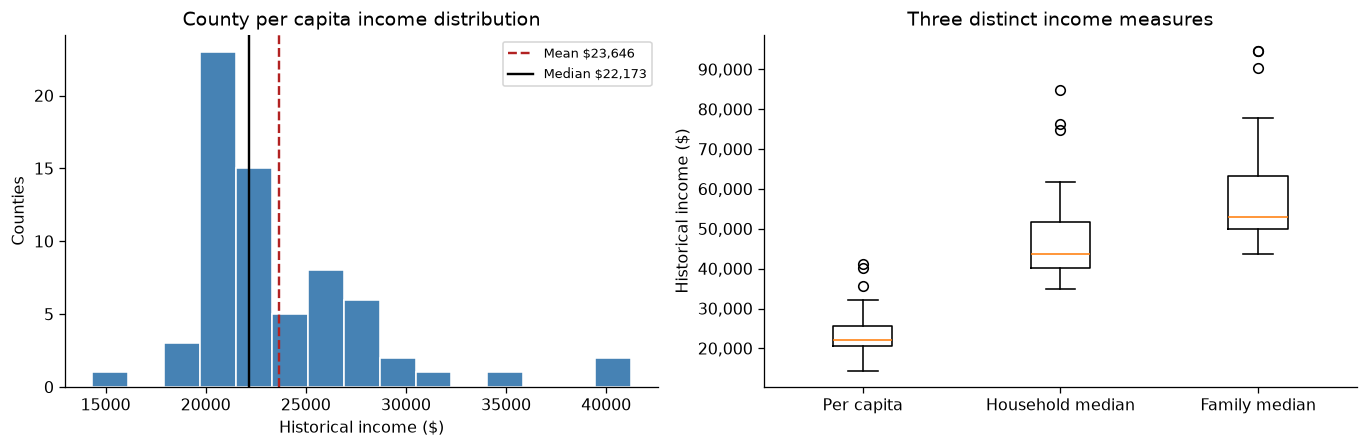

In [5]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].hist(pci,bins=15,color='steelblue',edgecolor='white')
axes[0].axvline(pci.mean(),color='firebrick',linestyle='--',label=f'Mean ${pci.mean():,.0f}')
axes[0].axvline(pci.median(),color='black',label=f'Median ${pci.median():,.0f}')
axes[0].set(title='County per capita income distribution',xlabel='Historical income ($)',ylabel='Counties')
axes[0].legend(fontsize=8)
axes[1].boxplot([income[c] for c in money_cols],tick_labels=['Per capita','Household median','Family median'])
axes[1].set(title='Three distinct income measures',ylabel='Historical income ($)')
for ax in axes: ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.tight_layout();plt.show()

The per capita distribution has a right tail: a few high-income counties lift its mean above its median. The household and family measures are higher partly because they measure different economic units, not because the same residents suddenly earn more. The boxplot compares distributions of county summaries, not individual household distributions.

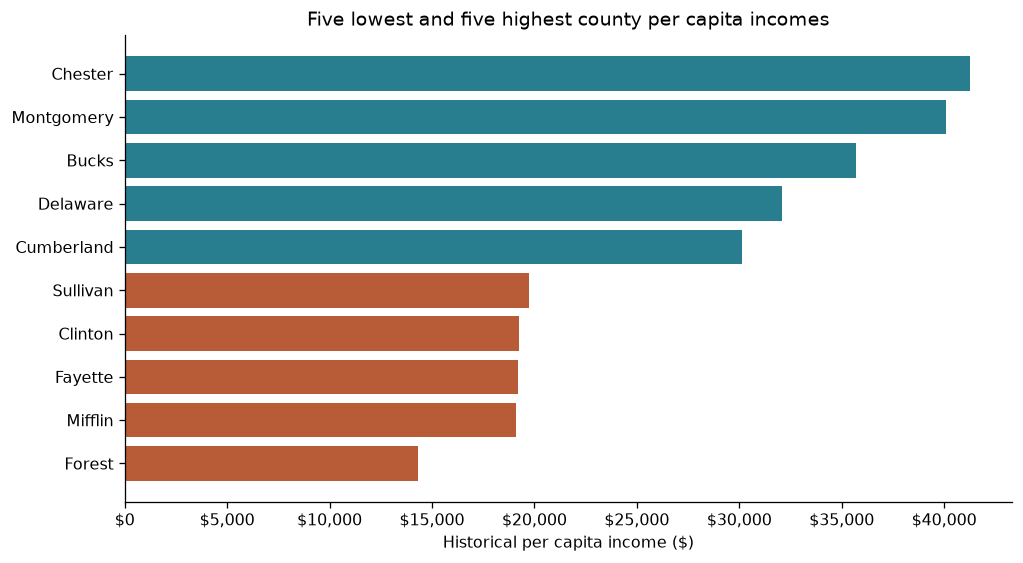

In [6]:
ranked=income.sort_values('Per capita income')
selected=pd.concat([ranked.head(5),ranked.tail(5)])
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(selected['County'],selected['Per capita income'],color=['#b85c38']*5+['#287d8e']*5)
ax.set(title='Five lowest and five highest county per capita incomes',xlabel='Historical per capita income ($)')
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.tight_layout();plt.show()

This ranking identifies the tails while keeping labels readable. Chester, Montgomery, and Bucks are among the high-income counties in this snapshot. A county's position does not establish why its income differs; geography, employment, demographics, and measurement can all matter.

## 5. Enrich with an outside source
The Gazetteer contributes new geographic fields and an independent county roster. I remove only the trailing “ County” suffix, validate a one-to-one join, and require all 67 counties to match. An outer audit reveals missing names in either source before any analysis.

In [7]:
gazetteer['County'] = gazetteer['NAME'].str.strip().str.replace(r' County$','',regex=True)
geo_cols=['County','GEOID','ALAND_SQMI','INTPTLAT','INTPTLONG']
geo=gazetteer[geo_cols].copy()
assert len(geo)==67 and geo['County'].is_unique and geo['GEOID'].is_unique
join_audit=income[['County']].merge(geo[['County']],on='County',how='outer',indicator=True,validate='one_to_one')
display(join_audit['_merge'].value_counts().rename('Counties').to_frame())
assert join_audit['_merge'].eq('both').all(), 'County names do not match: inspect join_audit.'
enriched=income.merge(geo,on='County',how='left',validate='one_to_one')
assert len(enriched)==len(income)==67
assert enriched[geo_cols].notna().all().all() and enriched['ALAND_SQMI'].gt(0).all()
display(enriched[['County','Per capita income','GEOID','ALAND_SQMI']].head())

,Counties
_merge,
both,67
left_only,0
right_only,0


,County,Per capita income,GEOID,ALAND_SQMI
0,Chester,41251,42029,750.55
1,Montgomery,40076,42091,482.97
2,Bucks,35687,42017,604.37
3,Delaware,32067,42045,183.81
4,Cumberland,30119,42041,545.48


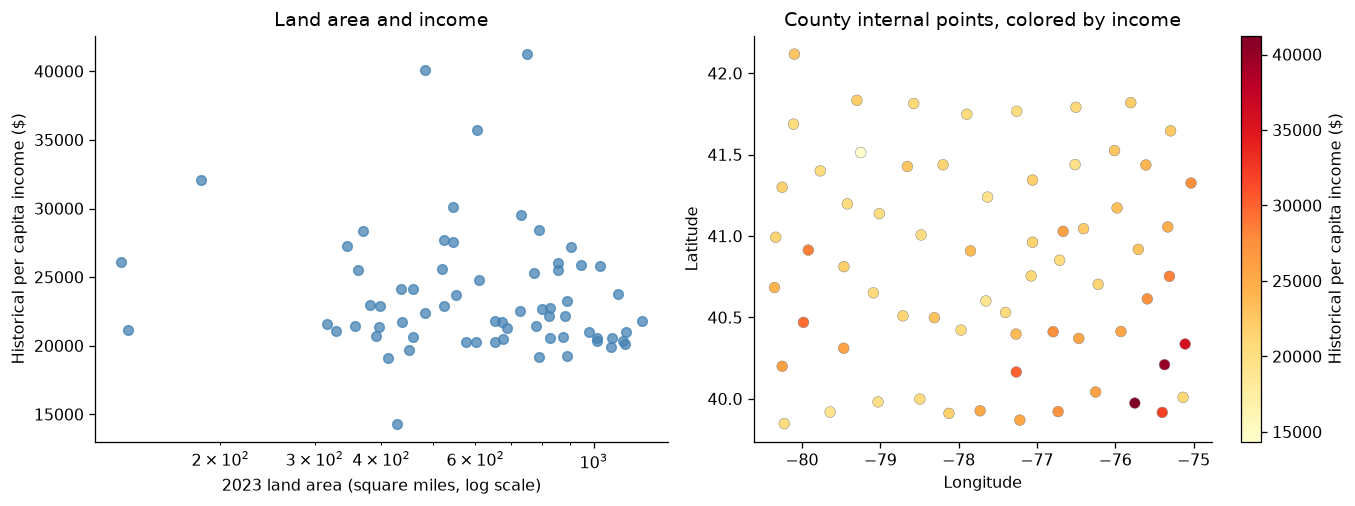

The Spearman rank correlation between land area and county per capita income is **-0.19**. This is a descriptive association, not a causal effect of land area. The point plot adds geographic context; it shows county internal points, not county boundaries or actual event locations.

In [8]:
fig,axes=plt.subplots(1,2,figsize=(12,4.5))
axes[0].scatter(enriched['ALAND_SQMI'],enriched['Per capita income'],alpha=.75,color='steelblue')
axes[0].set(xscale='log',title='Land area and income',xlabel='2023 land area (square miles, log scale)',ylabel='Historical per capita income ($)')
points=axes[1].scatter(enriched['INTPTLONG'],enriched['INTPTLAT'],c=enriched['Per capita income'],cmap='YlOrRd',s=45,edgecolors='gray',linewidths=.3)
axes[1].set(title='County internal points, colored by income',xlabel='Longitude',ylabel='Latitude')
fig.colorbar(points,ax=axes[1],label='Historical per capita income ($)')
plt.tight_layout();plt.show()
area_corr=enriched[['ALAND_SQMI','Per capita income']].corr(method='spearman').iloc[0,1]
display(Markdown(f"The Spearman rank correlation between land area and county per capita income is **{area_corr:.2f}**. "
    'This is a descriptive association, not a causal effect of land area. The point plot adds geographic context; '
    'it shows county internal points, not county boundaries or actual event locations.'))

## 6. Monte Carlo model and assumptions

Imagine a hypothetical program scheduling **30 events**. Each event independently selects one of the 67 counties with equal probability; repeat counties are permitted. The event inherits its location's historical county per capita income as a **context indicator**, not attendees' personal income.

For one simulated schedule, draw 30 values **with replacement** and calculate their arithmetic mean. Repeat for **10,000 schedules**. The question is:

**P(mean location county per capita income < $25,000).**

Using empirical resampling preserves the observed right tail without imposing a normal distribution. Equal county weights are a policy assumption, not population weights. Independence and repeat locations simplify logistics. This is a prospective scheduling scenario evaluated against a fixed historical baseline, not a forecast of future income. Income-estimate sampling error is not modeled.

In [9]:
income_values=enriched['Per capita income'].to_numpy(dtype=float)
n_events=30
n_trials=10000
threshold=25000.0
seed=5641
rng=np.random.default_rng(seed)  # set once, outside the loop

# One example schedule shows exactly what is aggregated.
example_rng=np.random.default_rng(seed)
example_values=example_rng.choice(income_values,size=n_events,replace=True)
print('Example schedule mean:',round(example_values.mean(),2))

results=[]
for trial in range(n_trials):
    event_incomes=rng.choice(income_values,size=n_events,replace=True)
    results.append(event_incomes.mean())
results=np.array(results)
assert len(results)==10000 and np.isfinite(results).all()
assert results.min()>=income_values.min() and results.max()<=income_values.max()

Example schedule mean: 22625.9


## 7. Results and probability interpretation
The histogram summarizes uncertainty across schedules. The 5th–95th percentile range contains approximately 90% of modeled schedule averages; it is not a confidence interval for the true statewide income.

,Estimate
Mean ($),"23,649.5948"
Median ($),"23,604.6500"
5th percentile ($),"22,340.1400"
95th percentile ($),"25,121.9600"
"P(mean < $25,000)",0.9373
Monte Carlo SE of probability,0.0024


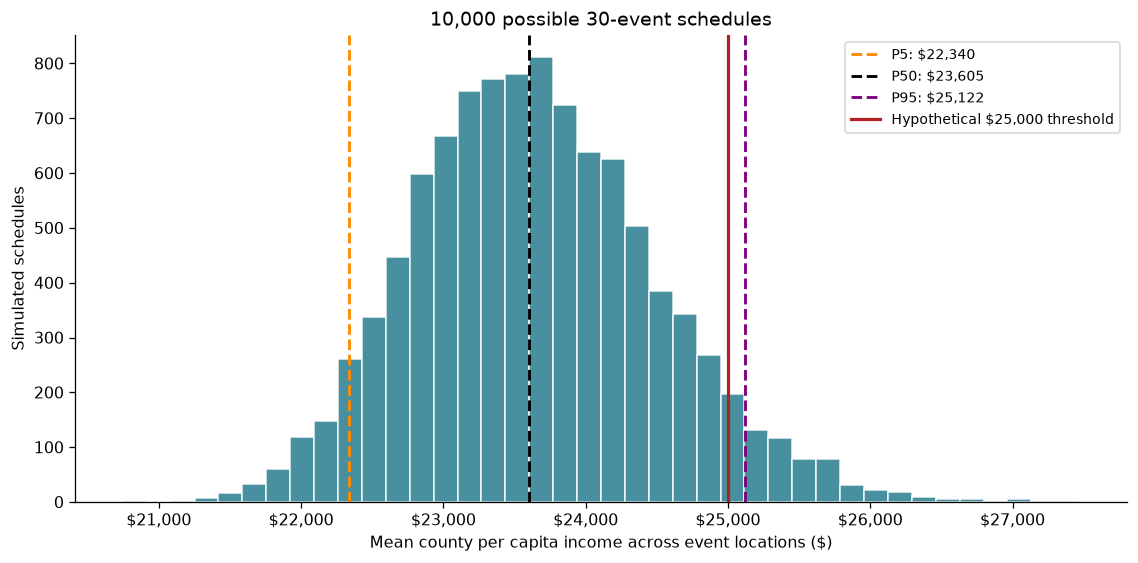

**Answer:** 9,373 of 10,000 simulated schedules fall below the threshold, giving an estimated probability of **93.73%**. The simulated mean is **$23,650**, and approximately 90% of schedule averages lie between **$22,340 and $25,122**. The Monte Carlo standard error of the probability is **0.24 percentage points**, reflecting simulation noise only.

In [10]:
p5,p50,p95=np.percentile(results,[5,50,95])
probability=np.mean(results<threshold)
mc_se=np.sqrt(probability*(1-probability)/n_trials)
summary=pd.Series({'Mean ($)':results.mean(),'Median ($)':p50,'5th percentile ($)':p5,
    '95th percentile ($)':p95,'P(mean < $25,000)':probability,'Monte Carlo SE of probability':mc_se})
display(summary.to_frame('Estimate').style.format({'Estimate':'{:,.4f}'}))
fig,ax=plt.subplots(figsize=(10,5))
ax.hist(results,bins=40,color='#287d8e',edgecolor='white',alpha=.85)
for q,value,color in zip([5,50,95],[p5,p50,p95],['darkorange','black','purple']):
    ax.axvline(value,color=color,linestyle='--',linewidth=1.8,label=f'P{q}: ${value:,.0f}')
ax.axvline(threshold,color='firebrick',linewidth=2,label='Hypothetical $25,000 threshold')
ax.set(title='10,000 possible 30-event schedules',xlabel='Mean county per capita income across event locations ($)',ylabel='Simulated schedules')
ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
ax.legend(fontsize=9);plt.tight_layout();plt.show()
display(Markdown(f"**Answer:** {np.count_nonzero(results<threshold):,} of {n_trials:,} simulated schedules fall below "
    f"the threshold, giving an estimated probability of **{probability:.2%}**. "
    f"The simulated mean is **${results.mean():,.0f}**, and approximately 90% of schedule averages lie "
    f"between **${p5:,.0f} and ${p95:,.0f}**. The Monte Carlo standard error of the probability is "
    f"**{100*mc_se:.2f} percentage points**, reflecting simulation noise only."))

## 8. Validation and sensitivity
For independent draws with replacement, the exact expected schedule average equals the mean of the empirical county distribution. Its standard deviation equals that distribution's standard deviation divided by the square root of 30. This gives a useful mathematical check. A separate seed-reset check confirms reproducibility.

In [11]:
expected_mean=income_values.mean()
expected_sd=income_values.std(ddof=0)/np.sqrt(n_events)
display(pd.DataFrame({'Quantity':['Mean','SD of schedule average'],
    'Analytical':[expected_mean,expected_sd], 'Simulated':[results.mean(),results.std(ddof=1)]}))
assert abs(results.mean()-expected_mean)<5*expected_sd/np.sqrt(n_trials)
check_rng=np.random.default_rng(seed)
repeated=np.array([check_rng.choice(income_values,n_events,replace=True).mean() for _ in range(n_trials)])
assert np.array_equal(results,repeated)
assert 0<=probability<=1
display(pd.DataFrame({'Hypothetical threshold ($)':[23000,24000,25000,26000],
    'Probability below threshold':[np.mean(results<t) for t in [23000,24000,25000,26000]]}).style.format({'Probability below threshold':'{:.2%}'}))
print('Validation passed: 67 unique matched counties, 10,000 finite outcomes, reproducible draws.')

,Quantity,Analytical,Simulated
0,Mean,"23,645.55","23,649.59"
1,SD of schedule average,834.02,850.93


,Hypothetical threshold ($),Probability below threshold
0,23000,22.89%
1,24000,67.59%
2,25000,93.73%
3,26000,99.38%


Validation passed: 67 unique matched counties, 10,000 finite outcomes, reproducible draws.


The sensitivity table shows that the probability depends on the chosen policy benchmark. It is not a universal statement about Pennsylvania. These checks validate the implementation under its assumptions; they do not validate the assumptions themselves.

## 9. Conclusion and limitations
The EDA documents substantial variation across county income summaries. Geographic enrichment supplies an independent coverage check and shows how income relates descriptively to land area and county location. The simulation turns this observed variation into a probability about **a 30-event schedule**, instead of reporting only an average.

The probability above can help compare a hypothetical schedule-selection policy with an income-context benchmark. It cannot show how many low-income people an event reaches. A real program would need current, verified socioeconomic data, participant information, travel constraints, and an explicit equitable allocation policy before making decisions.

Limitations include historical data, possible Wikipedia errors, different geographic/income vintages, equal county selection rather than population weighting, independent events, repeated counties, and no measurement-error model. Lower simulated income averages do not demonstrate program impact or causality.

**Attribution:** workflow adapted from Dr. Dave Wanik's OPIM 5641 M1.1 and M1.2 notebooks. This draft was prepared with AI assistance for code, explanations, and validation; the student should review the work and be able to explain the assumptions and each step. The separate handwritten math check is not included here.